<a href="https://colab.research.google.com/github/vinamrag-code/qpu-grovers-demo/blob/main/qpu_grovers_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-aer -q
!pip install pylatexenc -q

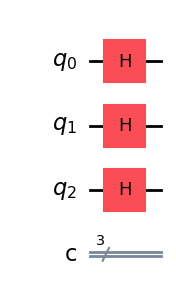

In [2]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 qubits = 8 possible states (our "8 glasses")
n_qubits = 3
qc = QuantumCircuit(n_qubits, n_qubits)

# Put all qubits into superposition — this is the "all glasses equal" starting state
qc.h(range(n_qubits))

qc.draw('mpl')

Secret number 5 in binary: 101


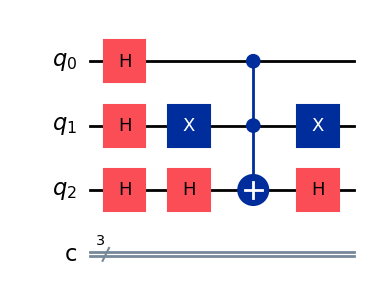

In [3]:
# Our secret number (change this to test different values 0-7)
secret_number = 5

# Convert to binary, padded to 3 bits (5 = 101)
binary = format(secret_number, f'0{n_qubits}b')
print(f"Secret number {secret_number} in binary: {binary}")

def add_oracle(qc, binary):
    # Step 1: Flip any qubit that should be '0' in our secret number
    # (so that ALL qubits temporarily read as '1' only for our secret combination)
    for i, bit in enumerate(reversed(binary)):
        if bit == '0':
            qc.x(i)

    # Step 2: Apply a multi-controlled Z gate
    # This flips the sign ONLY when all qubits are currently '1'
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)

    # Step 3: Undo the flips from Step 1 (put qubits back to normal)
    for i, bit in enumerate(reversed(binary)):
        if bit == '0':
            qc.x(i)

add_oracle(qc, binary)
qc.draw('mpl')

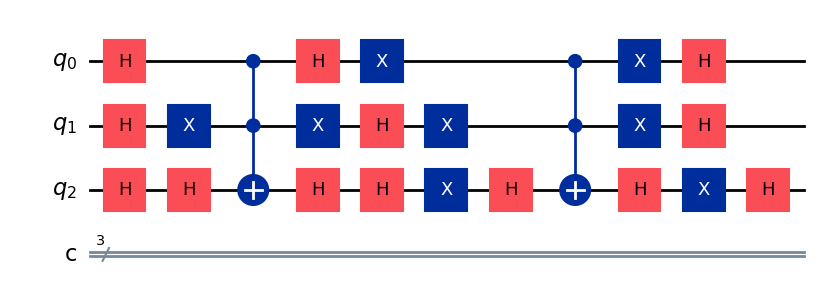

In [4]:
def add_diffuser(qc, n_qubits):
    # Step 1: Bring qubits back from superposition toward |0...0>
    qc.h(range(n_qubits))

    # Step 2: Flip all qubits (so |0...0> becomes |1...1>)
    qc.x(range(n_qubits))

    # Step 3: Multi-controlled Z gate again (same trick as the oracle)
    # This time it flips the sign of the |0...0> state specifically
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)

    # Step 4: Undo the X flips
    qc.x(range(n_qubits))

    # Step 5: Undo the Hadamards
    qc.h(range(n_qubits))

add_diffuser(qc, n_qubits)
qc.draw('mpl')

Optimal number of rounds for 8 possibilities: 2


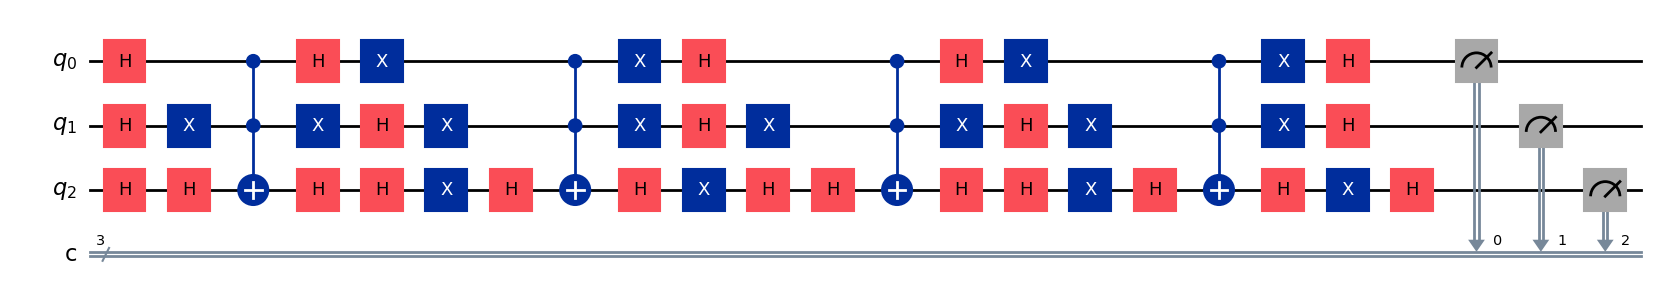

In [5]:
from qiskit_aer import AerSimulator
from qiskit import transpile

import math

# Optimal number of rounds for N possibilities: (pi/4) * sqrt(N)
N = 2 ** n_qubits
optimal_rounds = round((math.pi / 4) * math.sqrt(N))
print(f"Optimal number of rounds for {N} possibilities: {optimal_rounds}")

# Rebuild the circuit from scratch (clean slate)
qc = QuantumCircuit(n_qubits, n_qubits)

# Step 1: Superposition (all glasses equal)
qc.h(range(n_qubits))

# Step 2: Repeat oracle + diffuser the optimal number of times
for _ in range(optimal_rounds):
    add_oracle(qc, binary)
    add_diffuser(qc, n_qubits)

# Step 3: Measure all qubits into classical bits
qc.measure(range(n_qubits), range(n_qubits))

qc.draw('mpl')

In [6]:
# Set up the local simulator (our "pretend QPU")
simulator = AerSimulator()

# Transpile: converts our circuit into the exact gate set the simulator understands
compiled_circuit = transpile(qc, simulator)

# Run it — 1000 shots means we repeat the whole experiment 1000 times
# (remember: one measurement only gives one result, so we need many to see probabilities)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts()

print("Raw results (binary : count):")
print(counts)

# Plot as a histogram
plot_histogram(counts)
plt.show()

Raw results (binary : count):
{'110': 5, '010': 5, '000': 10, '100': 6, '011': 10, '111': 6, '001': 11, '101': 947}
